# Chapter 11 — GaAs phonon dispersion & DOS

Companion notebook to Chapter 11. We plot the Fourier-interpolated phonon
dispersion (`matdyn.x` → `gaas.freq.gp`) along L–Γ–X–W–K–Γ next to the
phonon DOS (`gaas.phdos`), and read off the LO–TO splitting at Γ.
Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

d = Path('../code/11-phonon-dispersion')

# matdyn .gp: one row per q-point -> col0 = q-distance, cols 1.. = freqs (cm^-1)
raw = np.loadtxt(d/'gaas.freq.gp')
qd = raw[:, 0]
freqs = raw[:, 1:]            # (nq, 3*nat)
print(f'{freqs.shape[1]} branches, {len(qd)} q-points; qdist 0..{qd.max():.3f}')

# High-symmetry ticks (2pi/alat), same path as the band structure
ticks  = [0.0, 0.8660, 1.8660, 2.3660, 2.7196, 3.7802]
labels = ['L', 'Γ', 'X', 'W', 'K', 'Γ']

# Optical TO/LO at the first Γ (q-distance ~0.866): the 3 highest branches
iG = np.argmin(np.abs(qd - 0.8660))
opt = np.sort(freqs[iG])[-3:]
TO, LO = opt[0], opt[-1]
print(f'At Γ: TO ≈ {TO:.1f} cm^-1, LO ≈ {LO:.1f} cm^-1, LO-TO splitting ≈ {LO-TO:.1f} cm^-1')

6 branches, 181 q-points; qdist 0..3.780
At Γ: TO ≈ 269.7 cm^-1, LO ≈ 284.0 cm^-1, LO-TO splitting ≈ 14.3 cm^-1


/tmp/ipykernel_3910539/1564241372.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


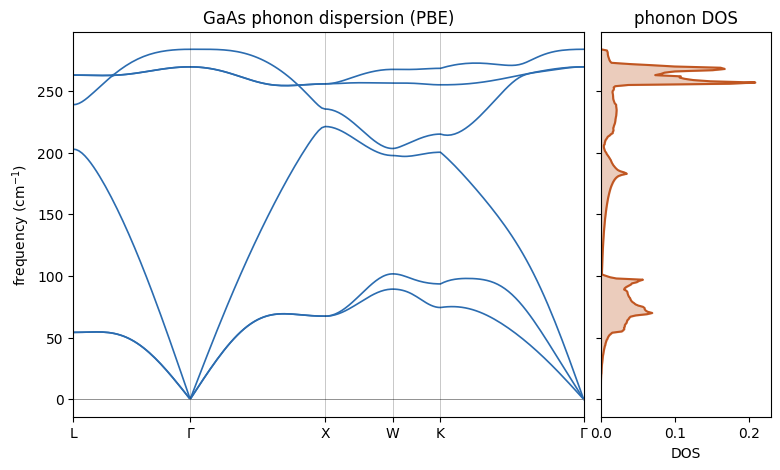

In [2]:
import matplotlib.pyplot as plt

phdos = np.loadtxt(d/'gaas.phdos')   # col0 = freq (cm^-1), col1 = DOS
fw, dos = phdos[:, 0], phdos[:, 1]

fig, (axb, axd) = plt.subplots(1, 2, figsize=(9, 5), sharey=True,
                               gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.05})
for b in range(freqs.shape[1]):
    axb.plot(qd, freqs[:, b], color='#2b6cb0', lw=1.2)
axb.axhline(0, color='gray', lw=0.6)
for x in ticks: axb.axvline(x, color='k', lw=0.5, alpha=0.3)
axb.set_xticks(ticks); axb.set_xticklabels(labels)
axb.set_xlim(qd.min(), qd.max())
axb.set_ylabel('frequency (cm$^{-1}$)')
axb.set_title('GaAs phonon dispersion (PBE)')

axd.plot(dos, fw, color='#c05621')
axd.fill_betweenx(fw, 0, dos, color='#c05621', alpha=0.3)
axd.set_xlim(0, dos.max()*1.1)
axd.set_xlabel('DOS')
axd.set_title('phonon DOS')
fig.tight_layout()
fig.savefig(d.parent.parent/'static/img/11-phonon-dispersion.png', dpi=120)
plt.show()

**What you see.** Three **acoustic** branches rise linearly from zero at Γ
(slopes = sound speeds); three **optical** branches sit above. At Γ the
optical modes split into a doubly-degenerate **TO** and a single, higher
**LO** — the LO–TO splitting from the Born charges and $\varepsilon_\infty$,
added by `matdyn.x` as the path approaches Γ. A non-polar crystal (Si)
would show LO = TO here. The **phonon DOS** peaks coincide with the flat
(high-DOS) regions of the dispersion — the van Hove singularities.